# Bitcoin Trend Analysis

This notebook analyzes Bitcoin price trends in the provided dataset across daily, weekly, and monthly intervals. It highlights the long-term direction, short-term volatility, and moving-average behavior so you can see how the trend changes over time.

Dataset: https://www.kaggle.com/datasets/kapturovalexander/bitcoin-and-ethereum-prices-from-start-to-2023?select=BTC-USD+%282014-2024%29.csv

Dataset period: 2014-09-18 to 2024-01-21
Starting close: 424.44
Ending close: 41,623.70
Overall return: 9,706.73%
Average daily return: 0.2034%
Daily return volatility: 3.6939%

Latest 5 weekly intervals:
               first      last      mean  weekly_change_%
Date                                                     
2023-12-24 42,623.54 43,016.12 43,309.86             0.92
2023-12-31 43,613.14 42,265.19 42,675.11            -3.09
2024-01-07 44,167.33 43,943.10 44,035.48            -0.51
2024-01-14 46,970.50 41,796.27 44,799.77           -11.02
2024-01-21 42,511.97 41,623.70 42,152.29            -2.09

Latest 5 monthly intervals:
               first      last      mean  monthly_change_%
Date                                                      
2023-09-30 25,800.72 26,967.92 26,306.14              4.52
2023-10-31 27,983.75 34,667.78 29,755.90             23.89
2023-11-30 35,437.25 37,712.75 36,596.16              6.42
2023-12-31 38,688.75 42,265.19 42,546.89              9.24
2024-0

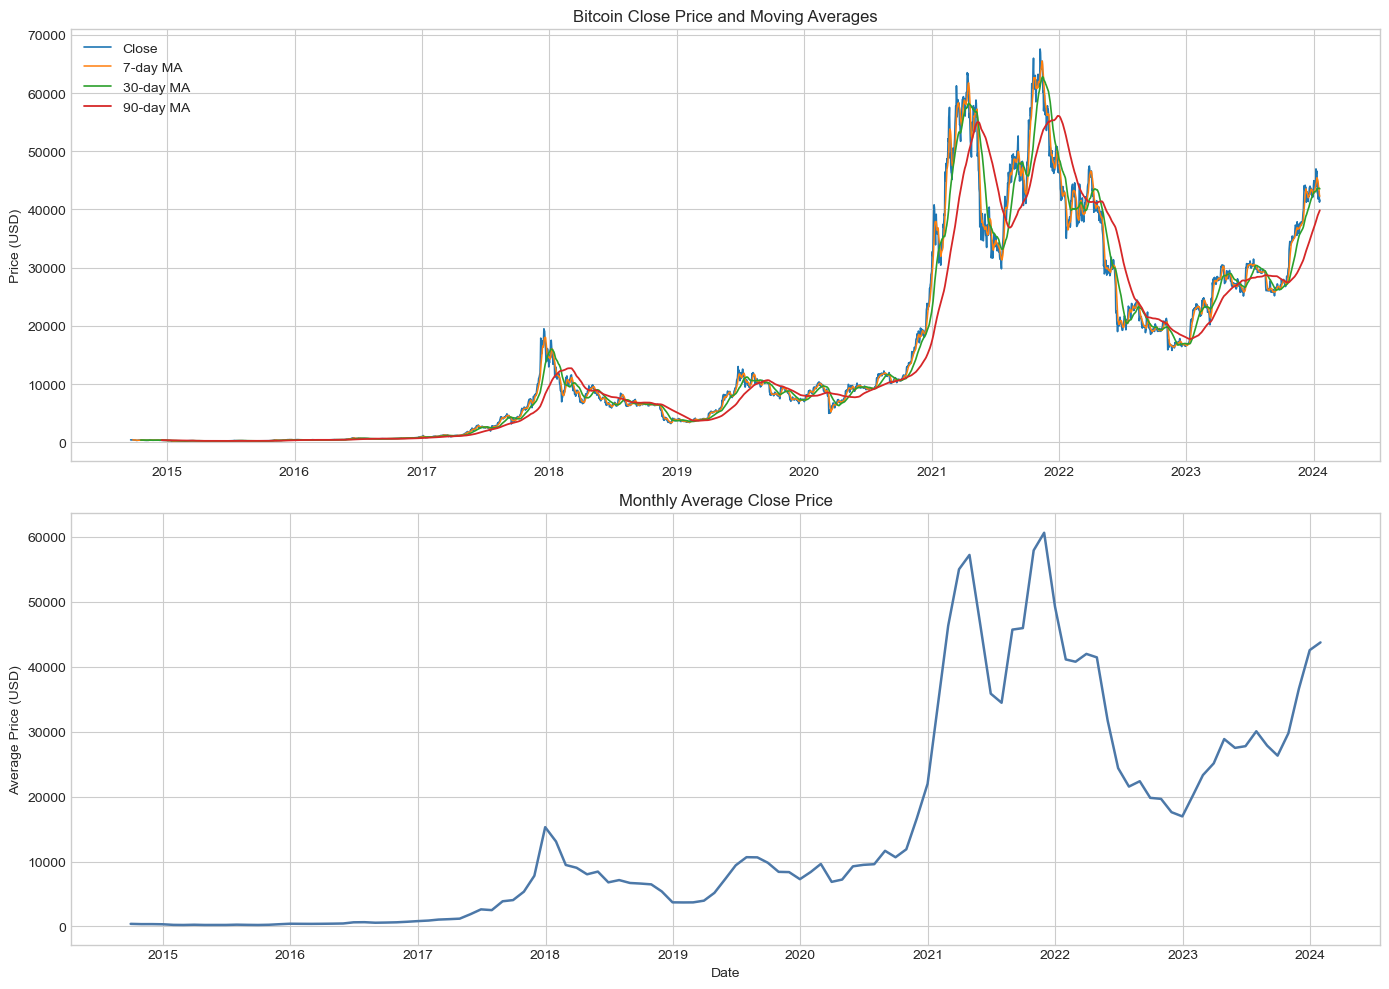

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Load the bitcoin dataset.
data_path = Path("dataset") / "btc.csv"
df = pd.read_csv(data_path, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Create a few time-based features for interval analysis.
df["Return_%"] = df["Close"].pct_change() * 100
df["MA_7"] = df["Close"].rolling(window=7).mean()
df["MA_30"] = df["Close"].rolling(window=30).mean()
df["MA_90"] = df["Close"].rolling(window=90).mean()

df_indexed = df.set_index("Date")

# Summarize trend behavior by week and month.
weekly = df_indexed["Close"].resample("W").agg(["first", "last", "mean", "min", "max"]).copy()
weekly["weekly_change_%"] = (weekly["last"] / weekly["first"] - 1) * 100
monthly = df_indexed["Close"].resample("ME").agg(["first", "last", "mean", "min", "max"]).copy()
monthly["monthly_change_%"] = (monthly["last"] / monthly["first"] - 1) * 100

# Basic long-term trend summary.
overall_return_pct = (df["Close"].iloc[-1] / df["Close"].iloc[0] - 1) * 100
average_daily_return = df["Return_%"].mean()
volatility = df["Return_%"].std()

print(f"Dataset period: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Starting close: {df['Close'].iloc[0]:,.2f}")
print(f"Ending close: {df['Close'].iloc[-1]:,.2f}")
print(f"Overall return: {overall_return_pct:,.2f}%")
print(f"Average daily return: {average_daily_return:,.4f}%")
print(f"Daily return volatility: {volatility:,.4f}%")

print("\nLatest 5 weekly intervals:")
print(weekly.tail(5)[["first", "last", "mean", "weekly_change_%"]])

print("\nLatest 5 monthly intervals:")
print(monthly.tail(5)[["first", "last", "mean", "monthly_change_%"]])

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

axes[0].plot(df["Date"], df["Close"], label="Close", color="#1f77b4", linewidth=1.2)
axes[0].plot(df["Date"], df["MA_7"], label="7-day MA", color="#ff7f0e", linewidth=1.1)
axes[0].plot(df["Date"], df["MA_30"], label="30-day MA", color="#2ca02c", linewidth=1.2)
axes[0].plot(df["Date"], df["MA_90"], label="90-day MA", color="#d62728", linewidth=1.3)
axes[0].set_title("Bitcoin Close Price and Moving Averages")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(loc="upper left")

monthly_avg = df_indexed["Close"].resample("ME").mean()
axes[1].plot(monthly_avg.index, monthly_avg.values, color="#4c78a8", linewidth=1.8)
axes[1].set_title("Monthly Average Close Price")
axes[1].set_ylabel("Average Price (USD)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

Linear trend slope (full dataset):
Slope: 12.7104 USD/day
Slope: 4,642.49 USD/year

Linear trend slope (2024 data only):
Slope: -162.0367 USD/day
Slope: -59,183.91 USD/year


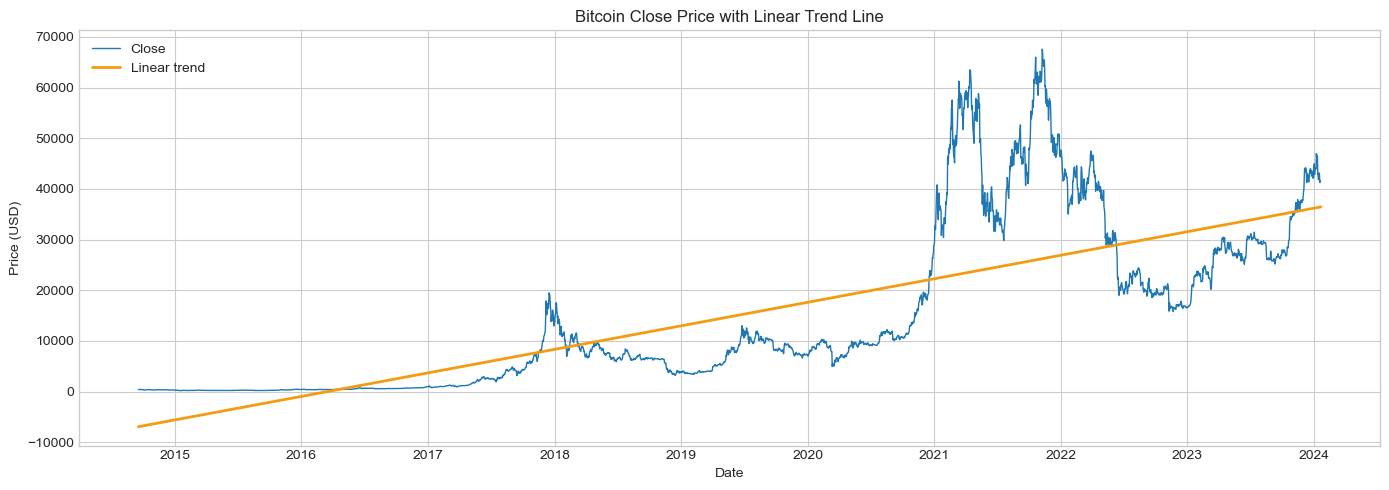

In [3]:
import numpy as np

# Subset 2024 data for year-specific trend.
df_2024 = df_indexed.loc["2024-01-01":"2024-12-31"]

# Linear trend slope for the full dataset.
all_days = (df["Date"] - df["Date"].min()).dt.days.to_numpy(dtype=float)
all_close = df["Close"].to_numpy(dtype=float)

mask_all = np.isfinite(all_days) & np.isfinite(all_close)
all_days = all_days[mask_all]
all_close = all_close[mask_all]

if len(all_days) > 1 and np.ptp(all_days) > 0:
    all_days_mean = all_days.mean()
    all_days_centered = all_days - all_days_mean
    slope_all, intercept_centered = np.polyfit(all_days_centered, all_close, 1)
    intercept_all = intercept_centered - slope_all * all_days_mean
    slope_all_year = slope_all * 365.25

    print("Linear trend slope (full dataset):")
    print(f"Slope: {slope_all:,.4f} USD/day")
    print(f"Slope: {slope_all_year:,.2f} USD/year")
else:
    slope_all = np.nan
    intercept_all = np.nan
    print("Not enough data to compute the full-dataset slope.")

# Linear trend slope for 2024 data only.
if len(df_2024) > 1:
    days_2024 = (df_2024.index - df_2024.index.min()).days.to_numpy(dtype=float)
    close_2024 = df_2024["Close"].to_numpy(dtype=float)
    mask_2024 = np.isfinite(days_2024) & np.isfinite(close_2024)
    days_2024 = days_2024[mask_2024]
    close_2024 = close_2024[mask_2024]

    if len(days_2024) > 1 and np.ptp(days_2024) > 0:
        days_2024_mean = days_2024.mean()
        days_2024_centered = days_2024 - days_2024_mean
        slope_2024, intercept_2024_centered = np.polyfit(days_2024_centered, close_2024, 1)
        intercept_2024 = intercept_2024_centered - slope_2024 * days_2024_mean
        slope_2024_year = slope_2024 * 365.25

        print("\nLinear trend slope (2024 data only):")
        print(f"Slope: {slope_2024:,.4f} USD/day")
        print(f"Slope: {slope_2024_year:,.2f} USD/year")
    else:
        print("\nNot enough variation in 2024 data to compute a slope.")
else:
    print("\nNot enough 2024 data points to compute a slope.")

# Plot the overall trend line against the close price.
if np.isfinite(slope_all):
    trend_line = intercept_all + slope_all * all_days

    plt.figure(figsize=(14, 5))
    plt.plot(df["Date"], df["Close"], label="Close", color="#1f77b4", linewidth=1)
    plt.plot(df["Date"].iloc[mask_all], trend_line, label="Linear trend", color="#f39c12", linewidth=2)
    plt.title("Bitcoin Close Price with Linear Trend Line")
    plt.ylabel("Price (USD)")
    plt.xlabel("Date")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

## Key Trend Takeaways

- The long-term Bitcoin trend is strongly upward, rising from about $424.44 to $41,623.70 across the dataset.
- The 7-day moving average reacts quickly to momentum shifts, while the 30-day and 90-day averages show the broader market cycle more clearly.
- Weekly intervals highlight short bursts of volatility, but monthly intervals make the major trend reversals easier to see.
- The most recent data shows a recovery phase after the 2022 drawdown, followed by a strong rebound into 2024.

## Trend Detection with Simple Moving Averages

This section detects the trend using a short and long simple moving average (SMA). A bullish trend is when the short SMA is above the long SMA, a bearish trend is when it is below, and a near-equal gap suggests a sideways trend.

SMA trend detection (50-day vs 200-day):
Latest SMA 50: 42,275.53
Latest SMA 200: 30,177.60
Gap: 12,097.93 USD (40.09%)
Trend label: uptrend
Crossover signal: no recent crossover


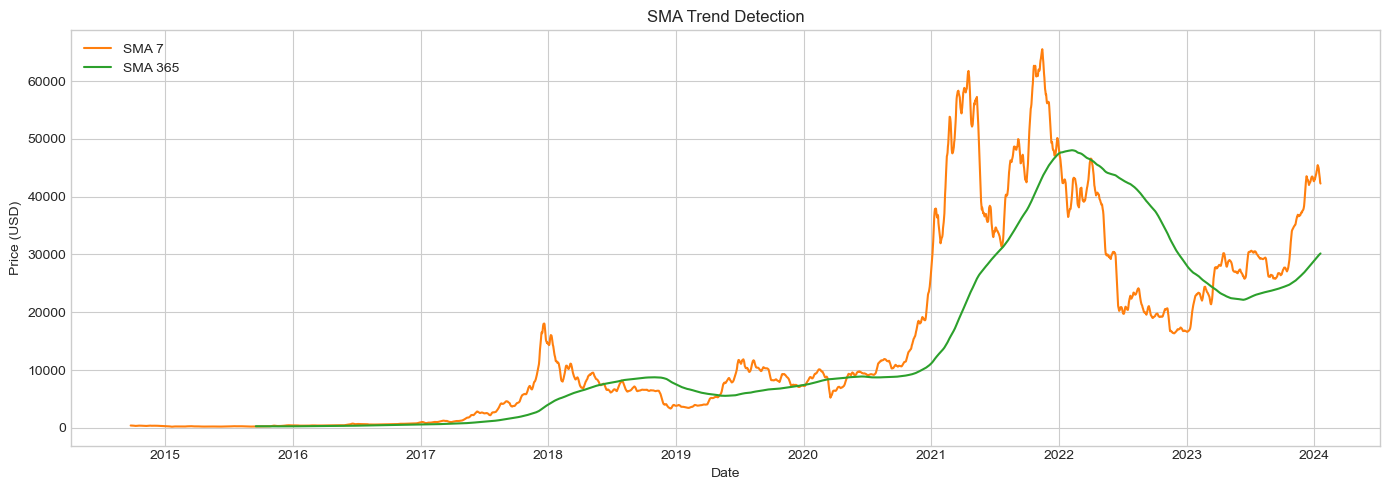

In [4]:
# Simple moving average (SMA) trend detection.
short_window = 7
long_window = 365

df["SMA_7"] = df["Close"].rolling(window=short_window).mean()
df["SMA_365"] = df["Close"].rolling(window=long_window).mean()

sma_data = df.dropna(subset=["SMA_7", "SMA_365"]).copy()

if sma_data.empty:
    print("Not enough data to compute SMA-based trend.")
else:
    latest = sma_data.iloc[-1]
    prev = sma_data.iloc[-2] if len(sma_data) > 1 else None
    diff = latest["SMA_7"] - latest["SMA_365"]
    pct_diff = (diff / latest["SMA_365"]) * 100

    threshold = 0.25  # percent difference to label a sideways trend
    if abs(pct_diff) < threshold:
        trend_label = "sideways"
    elif diff > 0:
        trend_label = "uptrend"
    else:
        trend_label = "downtrend"

    print("SMA trend detection (50-day vs 200-day):")
    print(f"Latest SMA 50: {latest['SMA_7']:,.2f}")
    print(f"Latest SMA 200: {latest['SMA_365']:,.2f}")
    print(f"Gap: {diff:,.2f} USD ({pct_diff:.2f}%)")
    print(f"Trend label: {trend_label}")

    if prev is not None:
        if prev["SMA_7"] <= prev["SMA_365"] and latest["SMA_7"] > latest["SMA_365"]:
            crossover = "bullish crossover"
        elif prev["SMA_7"] >= prev["SMA_365"] and latest["SMA_7"] < latest["SMA_365"]:
            crossover = "bearish crossover"
        else:
            crossover = "no recent crossover"
        print(f"Crossover signal: {crossover}")

    plt.figure(figsize=(14, 5))
    plt.plot(df["Date"], df["SMA_7"], label="SMA 7", color="#ff7f0e", linewidth=1.5)
    plt.plot(df["Date"], df["SMA_365"], label="SMA 365", color="#2ca02c", linewidth=1.5)
    plt.title("SMA Trend Detection")
    plt.ylabel("Price (USD)")
    plt.xlabel("Date")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

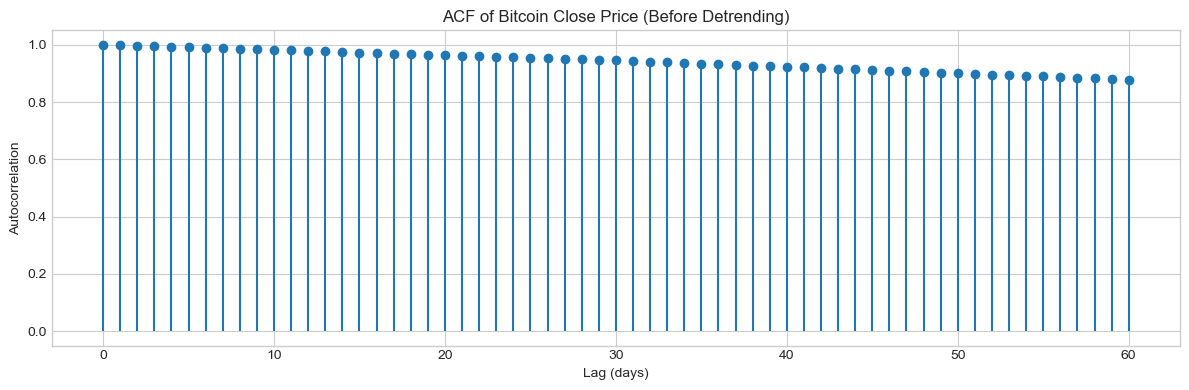

In [6]:
# ACF plot of the close price before detrending.
import numpy as np

close_series = df["Close"].dropna().to_numpy(dtype=float)
if close_series.size > 1:
    close_centered = close_series - close_series.mean()
    denom = np.sum(close_centered ** 2)

    if denom > 0:
        acf_full = np.correlate(close_centered, close_centered, mode="full")
        acf_vals = acf_full[close_series.size - 1 :] / denom
        max_lag = min(60, len(acf_vals) - 1)
        lags = np.arange(max_lag + 1)

        plt.figure(figsize=(12, 4))
        plt.stem(lags, acf_vals[: max_lag + 1], basefmt=" ")
        plt.title("ACF of Bitcoin Close Price (Before Detrending)")
        plt.xlabel("Lag (days)")
        plt.ylabel("Autocorrelation")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough variance to compute ACF.")
else:
    print("Not enough data to compute ACF.")

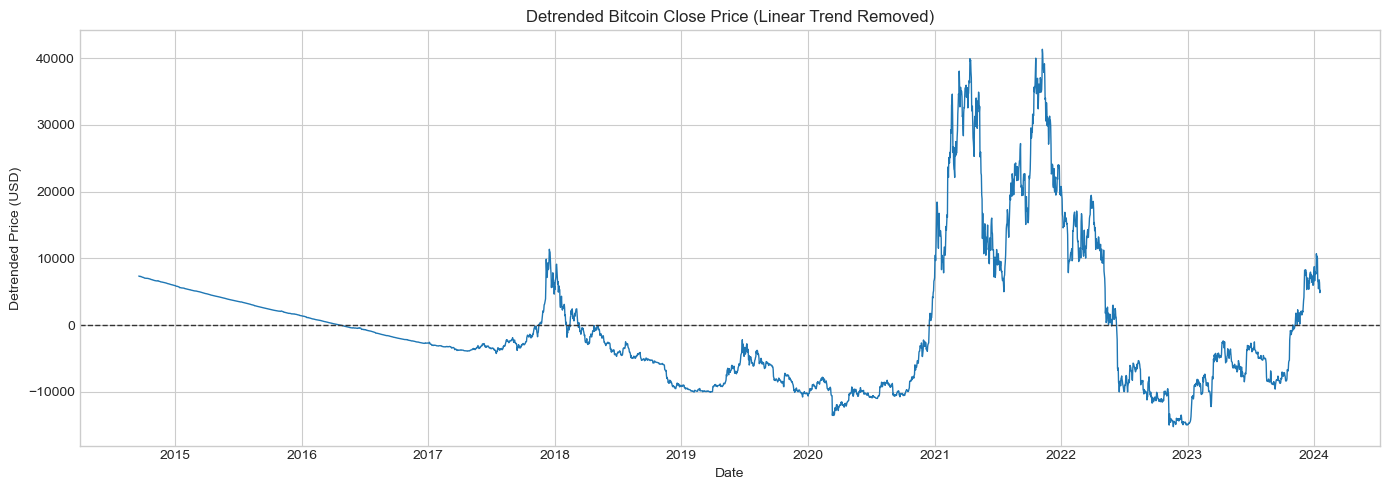

In [5]:
# Detrend the close price using a linear trend.
import numpy as np

detrend_days = (df["Date"] - df["Date"].min()).dt.days.to_numpy(dtype=float)
close_vals = df["Close"].to_numpy(dtype=float)
mask = np.isfinite(detrend_days) & np.isfinite(close_vals)

if mask.sum() > 1 and np.ptp(detrend_days[mask]) > 0:
    days_centered = detrend_days[mask] - detrend_days[mask].mean()
    slope, intercept_centered = np.polyfit(days_centered, close_vals[mask], 1)
    intercept = intercept_centered - slope * detrend_days[mask].mean()

    trend = intercept + slope * detrend_days
    df["Close_Detrended"] = df["Close"] - trend

    plt.figure(figsize=(14, 5))
    plt.plot(df["Date"], df["Close_Detrended"], color="#1f77b4", linewidth=1)
    plt.axhline(0, color="#333333", linewidth=1, linestyle="--")
    plt.title("Detrended Bitcoin Close Price (Linear Trend Removed)")
    plt.ylabel("Detrended Price (USD)")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to detrend.")

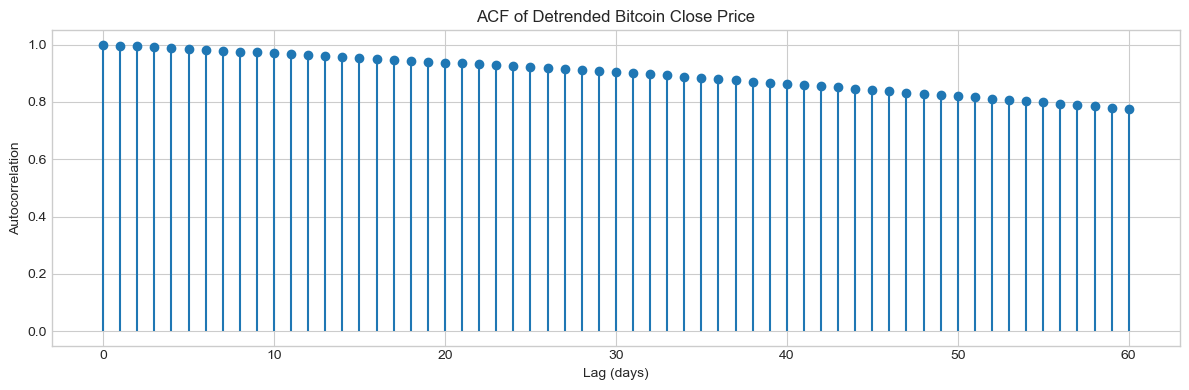

In [7]:
# ACF plot after detrending.
import numpy as np

if "Close_Detrended" not in df.columns:
    print("Run the detrending cell first to create Close_Detrended.")
else:
    detrended = df["Close_Detrended"].dropna().to_numpy(dtype=float)
    if detrended.size > 1:
        detrended_centered = detrended - detrended.mean()
        denom = np.sum(detrended_centered ** 2)

        if denom > 0:
            acf_full = np.correlate(detrended_centered, detrended_centered, mode="full")
            acf_vals = acf_full[detrended.size - 1 :] / denom
            max_lag = min(60, len(acf_vals) - 1)
            lags = np.arange(max_lag + 1)

            plt.figure(figsize=(12, 4))
            plt.stem(lags, acf_vals[: max_lag + 1], basefmt=" ")
            plt.title("ACF of Detrended Bitcoin Close Price")
            plt.xlabel("Lag (days)")
            plt.ylabel("Autocorrelation")
            plt.tight_layout()
            plt.show()
        else:
            print("Not enough variance to compute detrended ACF.")
    else:
        print("Not enough data to compute detrended ACF.")